# Data Loading

In [ ]:
import pandas as pd
import io
Rentals = pd.read_csv(io.BytesIO(uploaded['Rentals.csv']))

In [ ]:
Rentals.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   NAME                     978 non-null    object 
 1   host_identity_verified   983 non-null    object 
 2   borough                  980 non-null    object 
 3   neighborhood             976 non-null    object 
 4   lat                      977 non-null    float64
 5   long                     974 non-null    float64
 6   country                  974 non-null    object 
 7   country_code             978 non-null    object 
 8   cancellation_policy      982 non-null    object 
 9   room_type                981 non-null    object 
 10  year_constructed         980 non-null    float64
 11  price                    980 non-null    float64
 12  minimum_nights           975 non-null    float64
 13  number_of_reviews        973 non-null    float64
 14  rating                   

In [ ]:
Rentals["price"].describe()

,price
count,980.000000
mean,617.415306
std,339.577025
min,50.000000
25%,307.500000
50%,611.000000
75%,917.000000
max,1199.000000


In [ ]:
# Rentals_X= Rentals[[col for col in Rentals.columns if col != "price"]]
# Rentals_y=Rentals["price"]

In [ ]:
# from sklearn.model_selection import train_test_split

# X_train, X_test, y_train, y_test = train_test_split(rentals_X, rentals_y,test_size=0.15, random_state=42)

In [ ]:
from sklearn.model_selection import train_test_split

Rentals_training, Rentals_test = train_test_split(Rentals,test_size=0.15, random_state=42)

#Exploratory data analysis

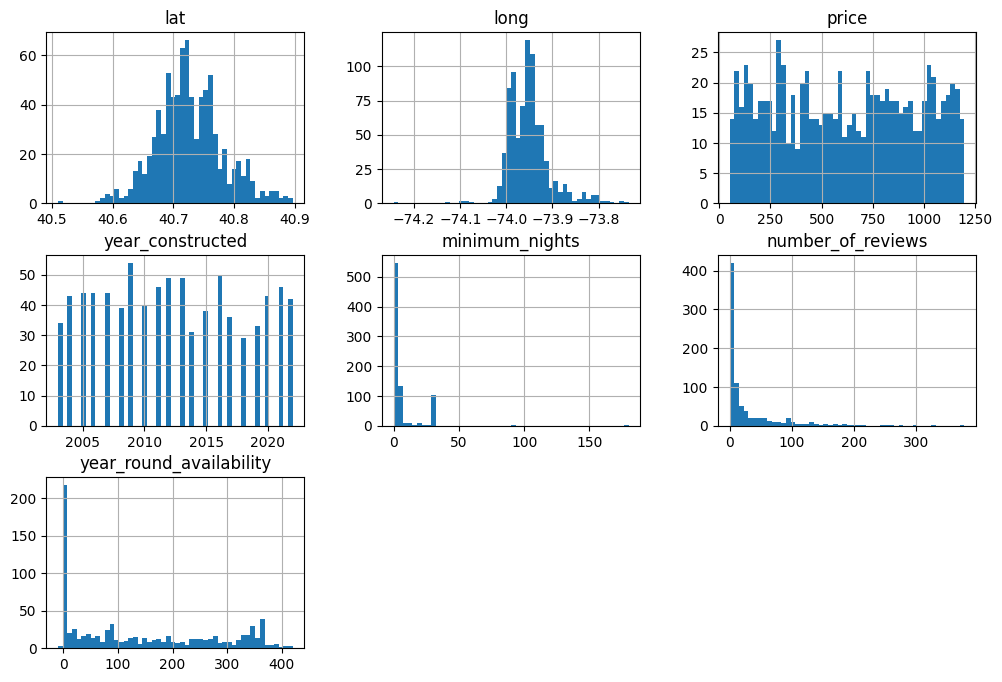

In [ ]:
import matplotlib.pyplot as plt

temp_hist=Rentals_training[["lat","long", "price", "year_constructed", "minimum_nights","number_of_reviews",
                 "year_round_availability"]]
temp_hist.hist(bins=50, figsize=(12,8))
plt.show()

In [ ]:
list_of_cat = ["NAME","host_identity_verified", "borough", "neighborhood",
               "country", "country_code", "cancellation_policy",
               "room_type", "rating"]
def unique_values_cat(a):
  for i in list_of_cat:
    print(f"{i}: {Rentals_training[i].nunique()}")

unique_values_cat(list_of_cat)

NAME: 831
host_identity_verified: 2
borough: 5
neighborhood: 113
country: 1
country_code: 1
cancellation_policy: 3
room_type: 3
rating: 7


In [ ]:
Rentals_training["room_type"].value_counts()

,count
room_type,
Entire home/apt,447
Private room,373
Shared room,14


#Feature Encoding

In [ ]:
from sklearn.preprocessing import OneHotEncoder

cat_features = Rentals_training[["borough", "room_type"]]
cat_encoder= OneHotEncoder(sparse_output=False)
cat_1hot= cat_encoder.fit_transform(cat_features)

cat_encoder.categories_

[array(['Bronx', 'Brooklyn', 'Manhattan', 'Queens', 'Staten Island', nan],
       dtype=object),
 array(['Entire home/apt', 'Private room', 'Shared room', nan],
       dtype=object)]

In [ ]:
# dropping country and country_code
Rentals_training = Rentals_training.drop(['country', 'country_code'], axis=1)
#axis=1 to drop columns

In [ ]:
#merge one hot encoded features
#get the feature names created
encoded_columns = cat_encoder.get_feature_names_out(["borough", "room_type"])

import pandas as pd
#create a new data frame from the encoded array with the index from rentals training data frame
df_output = pd.DataFrame(cat_1hot, columns=encoded_columns, index=Rentals_training.index)

#concatenate with the rentals_training df
#first drop original columns
df_dropped = Rentals_training.drop(columns =["borough", "room_type"], axis=1)

Rentals_training_final = pd.concat([df_dropped,df_output], axis=1)

Rentals_training_final.head()

,NAME,host_identity_verified,neighborhood,lat,long,cancellation_policy,year_constructed,price,minimum_nights,number_of_reviews,...,borough_Bronx,borough_Brooklyn,borough_Manhattan,borough_Queens,borough_Staten Island,borough_nan,room_type_Entire home/apt,room_type_Private room,room_type_Shared room,room_type_nan
643,Enormous Sunlit Room in Upper Manhattan,unconfirmed,Washington Heights,40.84755,-73.93825,moderate,2020.0,742.0,4.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
158,American Room @ Columbia Uni.,unconfirmed,Morningside Heights,40.80303,-73.96336,moderate,2012.0,599.0,1.0,48.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
977,Comfy bedroom in heart of Lower East Side,unconfirmed,Lower East Side,40.71937,-73.99202,strict,2009.0,1036.0,7.0,9.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
429,Cozy apartment in Brooklyn,unconfirmed,Bedford-Stuyvesant,40.69181,-73.94630,strict,2017.0,757.0,4.0,18.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
941,Prime west village! design 1BR~Best Value,verified,Greenwich Village,40.73478,-73.99791,moderate,2015.0,1066.0,29.0,8.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


#Handling Missing Data & Imputation

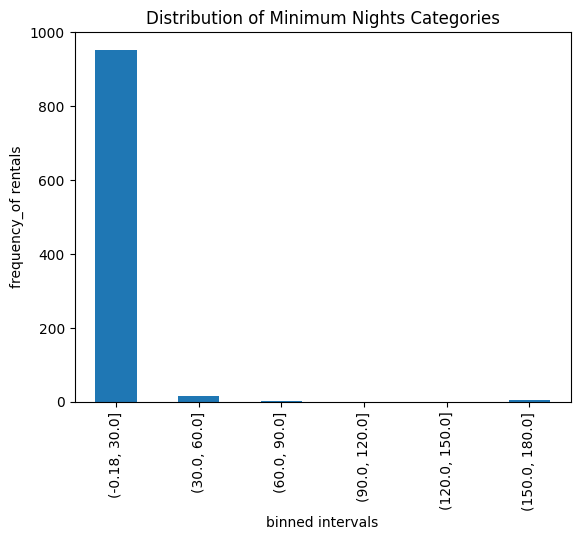

In [ ]:
import matplotlib.pyplot as plt
#6 category feature from minimum_nights
foo = Rentals['minimum_nights']

#creates a feature with 6 bin categories
Rentals["foo_cat"] = pd.cut(foo, bins=6)

#display
Rentals["foo_cat"].value_counts().sort_index().plot(kind='bar')

plt.title("Distribution of Minimum Nights Categories")
plt.xlabel("binned intervals")
plt.ylabel("frequency_of rentals")
plt.show()

In [ ]:
#Rentals['minimum_nights'].describe()
Rentals["foo_cat"].isna().sum()

np.int64(25)

In [ ]:
#get the most frequent category
most_frequent_bin = Rentals["foo_cat"].mode()[0]

#fill in NaNs in foo_cat with that bin
Rentals["foo_cat"] = Rentals["foo_cat"].fillna(most_frequent_bin)

In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit

foo_Rentals_training, foo_Rentals_test = train_test_split(Rentals, test_size =0.15, stratify= Rentals["foo_cat"], random_state =42)

In [ ]:
#proportions in the original data
print ("Rentals")
print(Rentals["foo_cat"].value_counts(normalize=True).sort_index())

#proportions in the training set
print("foo_Rentals_training")
print(foo_Rentals_training["foo_cat"].value_counts(normalize=True).sort_index())

#proportions in the test set
print("foo_Rentals_test")
print(foo_Rentals_test["foo_cat"].value_counts(normalize=True).sort_index())

Rentals
foo_cat
(-0.18, 30.0]     0.978
(30.0, 60.0]      0.015
(60.0, 90.0]      0.003
(90.0, 120.0]     0.000
(120.0, 150.0]    0.000
(150.0, 180.0]    0.004
Name: proportion, dtype: float64
foo_Rentals_training
foo_cat
(-0.18, 30.0]     0.977647
(30.0, 60.0]      0.015294
(60.0, 90.0]      0.003529
(90.0, 120.0]     0.000000
(120.0, 150.0]    0.000000
(150.0, 180.0]    0.003529
Name: proportion, dtype: float64
foo_Rentals_test
foo_cat
(-0.18, 30.0]     0.980000
(30.0, 60.0]      0.013333
(60.0, 90.0]      0.000000
(90.0, 120.0]     0.000000
(120.0, 150.0]    0.000000
(150.0, 180.0]    0.006667
Name: proportion, dtype: float64


In [ ]:
from sklearn.model_selection import train_test_split

def foo_cat_proportions(data):
    return data["foo_cat"].value_counts() / len(data)

#Create a Random Split (To see the difference)
rand_train, rand_test = train_test_split(
    Rentals, test_size=0.15, random_state=42
)

compare_props = pd.DataFrame({
    "Overall %": foo_cat_proportions(Rentals),
    "Stratified %": foo_cat_proportions(foo_Rentals_test),
    "Random %": foo_cat_proportions(rand_test),
}).sort_index()

compare_props.index.name = "foo Category"
compare_props["Strat. Error %"] = (compare_props["Stratified %"] /
                                   compare_props["Overall %"] - 1)
compare_props["Rand. Error %"] = (compare_props["Random %"] /
                                  compare_props["Overall %"] - 1)
(compare_props * 100).round(2)

,Overall %,Stratified %,Random %,Strat. Error %,Rand. Error %
foo Category,,,,,
"(-0.18, 30.0]",97.8,98.00,98.67,0.20,0.89
"(30.0, 60.0]",1.5,1.33,0.67,-11.11,-55.56
"(60.0, 90.0]",0.3,0.00,0.00,-100.00,-100.00
"(90.0, 120.0]",0.0,0.00,0.00,NaN,NaN
"(120.0, 150.0]",0.0,0.00,0.00,NaN,NaN
"(150.0, 180.0]",0.4,0.67,0.67,66.67,66.67


In [ ]:
#drop the foo feature minimum_nights from the foo split sets

foo_Rentals_training = foo_Rentals_training.drop("minimum_nights", axis=1)

foo_Rentals_test = foo_Rentals_test.drop("minimum_nights", axis=1)

In [ ]:
corr_matrix = Rentals_training.corr(numeric_only=True)
corr_matrix

,lat,long,year_constructed,price,minimum_nights,number_of_reviews,rating,year_round_availability
lat,1.000000,0.109140,0.040219,-0.006304,0.060050,-0.014785,0.042093,0.055509
long,0.109140,1.000000,0.045581,-0.018426,-0.119771,0.057533,0.000058,0.014735
year_constructed,0.040219,0.045581,1.000000,-0.009367,0.016428,0.009744,0.000139,-0.015356
price,-0.006304,-0.018426,-0.009367,1.000000,0.041089,-0.024363,0.033395,0.007831
minimum_nights,0.060050,-0.119771,0.016428,0.041089,1.000000,-0.089607,0.028661,0.183262
number_of_reviews,-0.014785,0.057533,0.009744,-0.024363,-0.089607,1.000000,-0.034001,0.148184
rating,0.042093,0.000058,0.000139,0.033395,0.028661,-0.034001,1.000000,-0.024039
year_round_availability,0.055509,0.014735,-0.015356,0.007831,0.183262,0.148184,-0.024039,1.000000


In [ ]:
corr_matrix["price"].sort_values(ascending=False)


,price
price,1.000000
minimum_nights,0.041089
rating,0.033395
year_round_availability,0.007831
lat,-0.006304
year_constructed,-0.009367
long,-0.018426
number_of_reviews,-0.024363


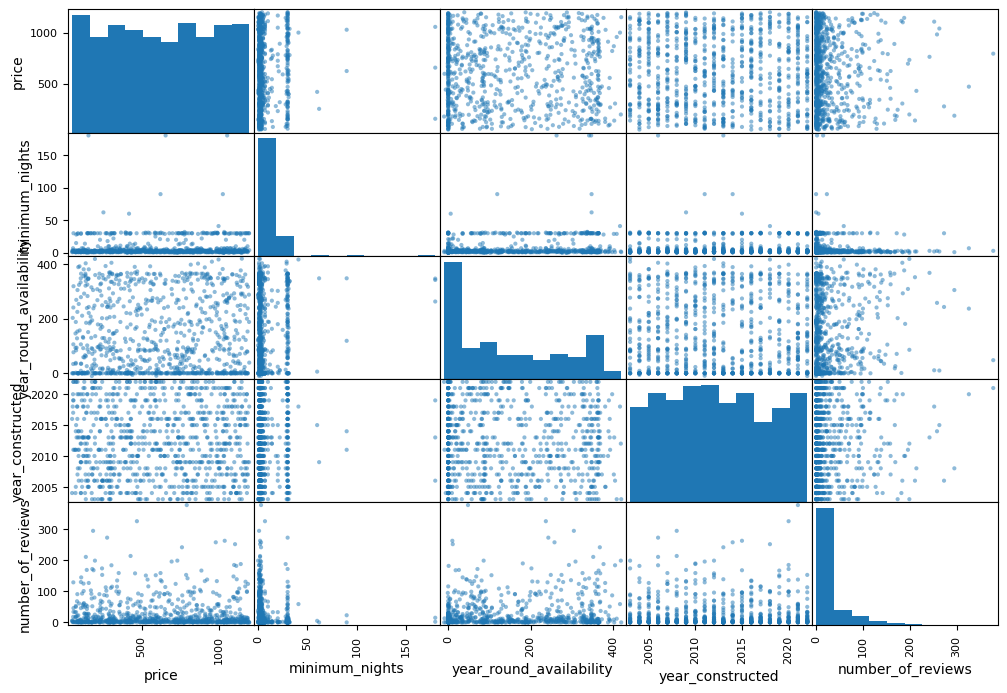

In [ ]:
from pandas.plotting import scatter_matrix

attributes = ["price", "minimum_nights",
              "year_round_availability", "year_constructed", "number_of_reviews"
              ]

scatter_matrix(Rentals_training[attributes], figsize=(12, 8))
plt.show()

In [ ]:
Rentals_training.isnull().sum()

,0
NAME,15
host_identity_verified,15
borough,18
neighborhood,21
lat,21
long,24
cancellation_policy,17
room_type,16
year_constructed,16
price,17


In [ ]:
from sklearn.impute import SimpleImputer
import numpy as np


imputer= SimpleImputer(strategy ="median")

#create a copy of the data with only numerical attributes
Rentals_training_num = Rentals_training.select_dtypes(include=[np.number])

#fit the imputer instance to the training data
imputer.fit(Rentals_training_num)

#strored in its statistics
imputer.statistics_


array([  40.72143 ,  -73.954655, 2012.      ,  620.      ,    3.      ,
          7.      ,    3.      ,   96.      ])

In [ ]:
#transform the training set with the learned median values
X= imputer.transform(Rentals_training_num)

Rentals_transformed = pd.DataFrame(X,
columns=Rentals_training_num.columns,index=Rentals_training_num.index)

In [ ]:
missing_list =[["NAME", "host_identity_verified", "borough",
                "neighborhood", "cancellation_policy",
                "room_type"]]
def fillMissing(a):
  for i in a:
    Rentals_training[i] = Rentals_training[i].fillna("Unknown")

fillMissing(missing_list)

Rentals_training.isnull().sum()

,0
NAME,0
host_identity_verified,0
borough,0
neighborhood,0
lat,21
long,24
cancellation_policy,0
room_type,0
year_constructed,16
price,17


In [ ]:
#select only the non-numeric columns from the original training set
Rentals_training_cat = Rentals_training.select_dtypes(exclude=[np.number])

#merge the cleaned numbers with the cleaned categories
Rentals_prepared = pd.concat([Rentals_transformed, Rentals_training_cat], axis=1)

In [ ]:
Rentals_prepared.isnull().sum()

,0
lat,0
long,0
year_constructed,0
price,0
minimum_nights,0
number_of_reviews,0
rating,0
year_round_availability,0
NAME,0
host_identity_verified,0


Encoding the room_type and borough of the cleaned data

In [ ]:
from sklearn.preprocessing import OneHotEncoder

cat_features = Rentals_prepared[["borough", "room_type"]]
cat_encoder= OneHotEncoder(sparse_output=False)
cat_1hot= cat_encoder.fit_transform(cat_features)

cat_encoder.categories_

KeyError: "None of [Index(['borough', 'room_type'], dtype='object')] are in the [columns]"

In [ ]:
#merge one hot encoded features
#get the feature names created
encoded_columns = cat_encoder.get_feature_names_out(["borough", "room_type"])

import pandas as pd
#create a new data frame from the encoded array with the index from rentals training data frame
df_output = pd.DataFrame(cat_1hot, columns=encoded_columns, index=Rentals_prepared.index)

#concatenate with the rentals_training df
#first drop original columns
# Create a temporary copy to drop columns from, to avoid KeyError on re-execution
temp_df = Rentals_prepared.copy()

# Check if columns exist before dropping
columns_to_drop = [col for col in ["borough", "room_type"] if col in temp_df.columns]
if columns_to_drop:
    df_dropped = temp_df.drop(columns=columns_to_drop, axis=1)
else:
    df_dropped = temp_df # If columns are already dropped, use temp_df as is

Rentals_prepared_final = pd.concat([df_dropped,df_output], axis=1)


Rentals_prepared = Rentals_prepared_final

Rentals_prepared.info()

<class 'pandas.core.frame.DataFrame'>
Index: 850 entries, 643 to 102
Data columns (total 32 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   lat                        850 non-null    float64
 1   long                       850 non-null    float64
 2   year_constructed           850 non-null    float64
 3   price                      850 non-null    float64
 4   minimum_nights             850 non-null    float64
 5   number_of_reviews          850 non-null    float64
 6   rating                     850 non-null    float64
 7   year_round_availability    850 non-null    float64
 8   NAME                       850 non-null    object 
 9   host_identity_verified     850 non-null    object 
 10  neighborhood               850 non-null    object 
 11  cancellation_policy        850 non-null    object 
 12  borough_Bronx              850 non-null    float64
 13  borough_Brooklyn           850 non-null    float64
 1